In [1]:
import sys
import pandas as pd
import numpy as np
import nest_asyncio

# Apply nest_asyncio to allow nested event loops in Jupyter
nest_asyncio.apply()

sys.path.append('../..')
from utils.tagging.label_creation_cisc import AutoTaggerServiceNow 

In [2]:
# Initialize with use_async=True for efficient N-sampling
# max_workers helps control the "outer" concurrency (batches of tickets)
tagger = AutoTaggerServiceNow(use_async=True, max_workers=5)

# Test connection
tagger.test_connection()

INFO:httpx:HTTP Request: POST https://ai-coe-openai-models.openai.azure.com/openai/deployments/gpt-5/chat/completions?api-version=2025-01-01-preview "HTTP/1.1 200 OK"
INFO:utils.tagging.label_creation_cisc:✓ Connection successful!


True

In [3]:
df = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/masked/data_masked.csv')

# Concat title, description and assignment_group
df['text'] = df['title'] + ' ' + df['description'] + ' ' + df['assignment_group']

# Create a small sample to test
df_test = df[["number", "text"]].sample(n=10, random_state=42)

In [4]:
# Run predictions with Confidence-Informed Self-Consistency (CISC)
# - mode='cisc': Activates the sample-and-aggregate pipeline
# - n_samples=5: Runs 5 independent reasoning paths per ticket
# - Output: A CSV with 'scientific_confidence' and 'consistency' columns

result_df = tagger.predict_and_create_csv(
    df=df_test,
    output_path='../../data/prediction_results_cisc.csv', # Changed filename
    number_column='number',
    text_column='text',
    mode='cisc',       # <--- CRITICAL CHANGE
    n_samples=5,       # <--- CRITICAL CHANGE
    semaphore_limit=10 # Lower this if you hit Rate Limits (5 samples * 10 tickets = 50 concurrent calls)
)

print(f"\nTotal predictions: {len(result_df)}")
print(f"Unique tickets: {result_df['number'].nunique()}")

# Verify the new columns
# You should see: 'scientific_confidence', 'consistency', 'reasoning_confidence'
result_df.head(10)

Processing (CISC):  20%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   | 2/10 [00:11<00:39,  4.94s/it]I


Total predictions: 10
Unique tickets: 10


,number,text,label,reasoning,scientific_confidence,reasoning_confidence,consistency
0,INC0152335,Support - Login/My YouSee/Migrated Customer (b...,"(1g Self service, 2g Mit YouSee), 3 Login issues","Tag: (1g Self service, 2g Mit YouSee), 3 Login...",0.9748,0.92,1.0
1,INC0127508,Support - Dawn/With Customer context/Tickets/O...,"(1 Misc incidents, 2 Other), 3 Tickets","(1 Misc incidents, 2 Other), 3 Tickets\nReason...",0.6630,0.85,0.6
2,INC0147628,[FO seq: 72500] Support - Issues with ongoing ...,"(1d Broadband, 2d Fiber), 3 Order activation","(1d Broadband, 2d Fiber), 3 Order activation\n...",0.9652,0.90,1.0
3,INC0140064,Change of ownership split on two different day...,"(1 Misc incidents, 2 Other), 3 Change ownership","(1 Misc incidents, 2 Other), 3 Change ownershi...",0.9268,0.78,1.0
4,INC0130075,[Stuck pending cancelation]]Support - Dawn/Wit...,"(1c TV, 2c COAX), 3 Order activation","Tag: (1c TV, 2c COAX), 3 Order activation\nRea...",0.9604,0.90,1.0
5,INC0136567,Support - YouSee mail/Issue with Mit YouSee/Ch...,"(1g Self service, 2g Mit YouSee), 3 technical ...","Tag: (1g Self service, 2g Mit YouSee), 3 techn...",0.6680,0.84,0.6
6,INC0131543,[FO seq: 40600]Support - Dawn/Quotation/Cannot...,"(1c TV, 2c Fiber), 3 Order activation","(1c TV, 2c Fiber), 3 Order activation\nReasoni...",0.5230,0.82,0.4
7,INC0144163,Support - TV/Video on demand/SmartTV Creating ...,"(1g Self service, 2g YS-play), 3 technical issues","(1g Self service, 2g YS-play), 3 technical iss...",0.6750,0.88,0.6
8,INC0130403,Support - Dawn/With Customer context/Products/...,"(1a MV Mobile voice, 2a Main product), 3 Perfo...","Tag: (1a MV Mobile voice, 2a Main product), 3 ...",0.6680,0.86,0.6
9,INC0144193,Support - TV/Other/Other Customer experiences ...,"(1c TV, 2c OTT), 3 technical issues","Tag: (1c TV, 2c OTT), 3 technical issues\nReas...",0.7722,0.78,0.8


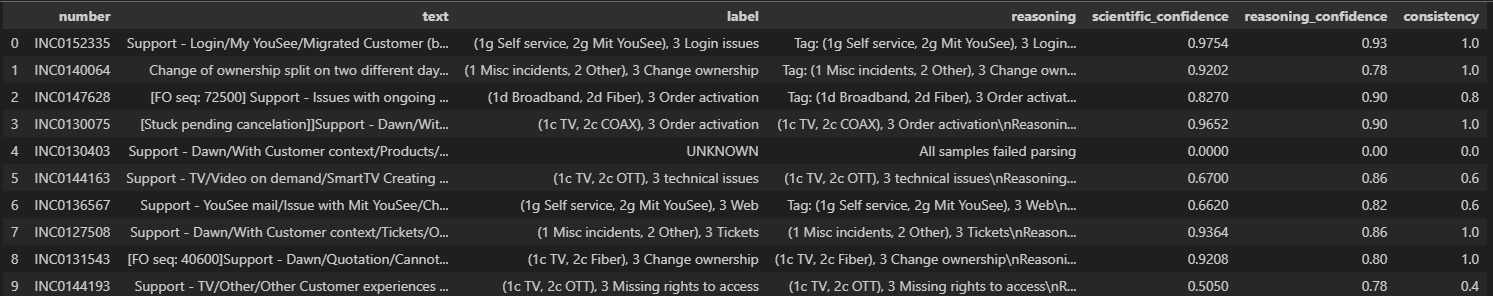

In [5]:
df_x = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/masked/data_masked.csv')

import pandas as pd

# Set width to None to show the full content regardless of length
pd.set_option('display.max_colwidth', None)

# Now when you print, it won't truncate
# Select the row and only the specific columns you want
row = df_x.loc[df_x['number'] == 'INC0130403', ['title', 'description', 'assignment_group']].iloc[0]

# Display the result
print(row)

title                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            Support - Dawn/With Customer context/Products/Other
description         The customer often experiences having E coverage. Everything looks fine in HLR, and she has plenty of data left.\n\nCategory: Dawn/With customer context/Products/Other  \nerrorURL: https://wp-host-app-prod-bss.prod01.nc.nuuday.nu/customer/residential/products/services?customerId=912e5b1d-9e60-48ba-aba5-a6e111ede0a3  \nexpectedBehaviour: Investigate if there is anything affecting her coverage  \nstepsToReproduce: The customer of

In [6]:
# Check the raw output for the ticket that failed (Index 4)
failed_ticket_text = df_test.iloc[4]['text']

# Ask the model again and print exactly what it says
raw_response = tagger.predict_tags_with_llm(failed_ticket_text, n=1, temperature=1.0)

print("--- WHAT THE LLM WROTE ---")
print(raw_response)

INFO:httpx:HTTP Request: POST https://ai-coe-openai-models.openai.azure.com/openai/deployments/gpt-5/chat/completions?api-version=2025-01-01-preview "HTTP/1.1 200 OK"


--- WHAT THE LLM WROTE ---
Tag: (1a MV Mobile voice, 2a Main product), 3 Performance issues
Reasoning: The customer’s phone frequently falls back to E/EDGE despite HLR and data being fine, indicating a network coverage/quality issue on a standard mobile subscription.
Reasoning_Confidence: 0.88
Label_Confidence: 0.88


In [7]:
# Check the raw output for the ticket that failed (Index 4)
failed_ticket_text = df_test.iloc[3]['text']

# Ask the model again and print exactly what it says
raw_response = tagger.predict_tags_with_llm(failed_ticket_text, n=1, temperature=1.0)

print("--- WHAT THE LLM WROTE ---")
print(raw_response)

INFO:httpx:HTTP Request: POST https://ai-coe-openai-models.openai.azure.com/openai/deployments/gpt-5/chat/completions?api-version=2025-01-01-preview "HTTP/1.1 200 OK"


--- WHAT THE LLM WROTE ---
Tag: (1g Self service, 2g Mit YouSee), 3 Web
Reasoning: The customer is trying to change the YouSee mail (POP3) password via the My YouSee portal and receives a generic error, indicating a web portal functionality issue within Mit YouSee rather than a mail login problem.
Reasoning_Confidence: 0.82
Label_Confidence: 0.80
